### Load Data from Google Drive

First, we need to mount Google Drive to access files stored there. This will prompt you to authenticate your Google account.

In [ ]:
!pip install gensim tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.1 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now, we can load your file. Assuming it's a CSV file and located in the root of your Google Drive, you can use the following code. If the file is in a different format (like Excel or JSON) or in a subfolder, you'll need to adjust the path and the `pd.read_` function accordingly.

In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/FoodFacts.products.170k_May26.csv' # Adjust the file extension and path if needed

df_row = pd.read_csv(file_path)



/tmp/ipykernel_6790/4187212963.py:5: DtypeWarning: Columns (0,1,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,

In [ ]:
print("Shape:", df_row.shape)

print("\nColumns:")
print(df_row.columns.tolist())

print("\nTarget Distribution:")
print(df_row["ecoscore_grade"].value_counts(dropna=False))

Shape: (171490, 509)

Columns:
['_id', 'product_name_en', 'ecoscore_grade', 'ingredients_text_en', 'categories', 'categories_hierarchy[0]', 'categories_hierarchy[1]', 'categories_hierarchy[2]', 'categories_hierarchy[3]', 'categories_hierarchy[4]', 'categories_hierarchy[5]', 'categories_hierarchy[6]', 'categories_hierarchy[7]', 'categories_hierarchy[8]', 'categories_hierarchy[9]', 'categories_hierarchy[10]', 'categories_hierarchy[11]', 'categories_hierarchy[12]', 'categories_hierarchy[13]', 'categories_hierarchy[14]', 'categories_hierarchy[15]', 'categories_hierarchy[16]', 'categories_hierarchy[17]', 'categories_hierarchy[18]', 'categories_hierarchy[19]', 'categories_hierarchy[20]', 'categories_hierarchy[21]', 'categories_hierarchy[22]', 'categories_hierarchy[23]', 'categories_hierarchy[24]', 'categories_hierarchy[25]', 'categories_hierarchy[26]', 'categories_hierarchy[27]', 'categories_hierarchy[28]', 'categories_hierarchy[29]', 'categories_hierarchy[30]', 'categories_hierarchy[31]', '

In [ ]:
missing = (
    df_row.isnull().sum()
    .sort_values(ascending=False)
)

print(missing.head(30))

Unnamed: 48                   171490
Unnamed: 47                   171490
packaging_hierarchy[49]       171489
packaging_hierarchy[50]       171489
packaging_hierarchy[52]       171489
packaging_hierarchy[51]       171489
packaging_hierarchy[46]       171489
ingredients_hierarchy[322]    171489
ingredients_hierarchy[323]    171489
ingredients_hierarchy[324]    171489
ingredients_hierarchy[335]    171489
ingredients_hierarchy[334]    171489
packaging_hierarchy[48]       171489
packaging_hierarchy[47]       171489
ingredients_hierarchy[360]    171489
ingredients_hierarchy[361]    171489
countries_hierarchy[22]       171489
countries_hierarchy[23]       171489
ingredients_hierarchy[362]    171489
ingredients_hierarchy[363]    171489
categories_hierarchy[41]      171489
ingredients_hierarchy[336]    171489
ingredients_hierarchy[343]    171489
ingredients_hierarchy[342]    171489
ingredients_hierarchy[344]    171489
ingredients_hierarchy[333]    171489
ingredients_hierarchy[330]    171489
i

In [ ]:
print(df_row['categories'].head(10))

0    Beverages and beverages preparations, Beverage...
1    Dranken en drankbereidingen,Dranken,Alcoholisc...
2                                             Biscuits
3                                      Green tapenades
4                                     Chocolate Cookie
5    Alimentos y bebidas de origen vegetal, Aliment...
6    Plant-based foods and beverages, Plant-based f...
7    Dairies, Desserts, Dairy desserts, fr:cremes-b...
8    Plant-based foods and beverages, Plant-based f...
9    Plant-based foods and beverages, Plant-based f...
Name: categories, dtype: object


In [ ]:
print(df_row['categories'].sample(10, random_state=42))

11471     Snacks, Sweet snacks, Biscuits and cakes, Cake...
40178     Snacks, Snacks sucrés, Cacao et dérivés, Choco...
28971     Snacks,Sweet snacks,Cocoa and its products,Cho...
136286    en:Breakfasts, en:Spreads, en:Sweet spreads, e...
9293      Plant-based foods and beverages, Plant-based f...
166680                       Dairies, Milks, en:whole-milks
67987                                    Sweeteners, Sugars
144395    Alimentos y bebidas de origen vegetal, Aliment...
100107    Plant-based foods and beverages, Plant-based f...
124486                Condiments, Sauces, Sauces à la crème
Name: categories, dtype: object


In [ ]:
df_row['categories'].isnull().sum()

np.int64(5)

In [ ]:
ingredient_cols = [
    c for c in df_row.columns
    if 'ingredients_hierarchy[' in c
]

In [ ]:
category_cols = [
    c for c in df_row.columns
    if 'categories_hierarchy[' in c
]

In [ ]:
print(len(ingredient_cols))
print(len(category_cols))

365
42


In [ ]:
def merge_hierarchy(row):

    values = []

    for item in row:

        if pd.notnull(item):

            item = str(item)

            item = item.replace('en:', '')
            item = item.replace('-', ' ')
            item = item.strip()

            if item:
                values.append(item)

    values = list(dict.fromkeys(values))

    return ' '.join(values)

In [ ]:

df_row['ingredient_hierarchy_text'] = (
    df_row[ingredient_cols]
    .apply(merge_hierarchy, axis=1)
)
df_row['category_hierarchy_text'] = (
    df_row[category_cols]
    .apply(merge_hierarchy, axis=1)
)

In [ ]:
print(df_row['ingredient_hierarchy_text'].head())
print("*"*50)
print(df_row['category_hierarchy_text'].head())

0    sugar added sugar disaccharide whole milk dair...
1                                                     
2                                                     
3                                                     
4                                                  dog
Name: ingredient_hierarchy_text, dtype: object
**************************************************
0    beverages and beverages preparations plant bas...
1    beverages and beverages preparations beverages...
2      snacks sweet snacks biscuits and cakes biscuits
3     spreads salted spreads tapenades green tapenades
4    snacks sweet snacks biscuits and cakes biscuit...
Name: category_hierarchy_text, dtype: object


In [ ]:
print(
    df_row[
        [
            'product_name_en',
            'ingredients_text_en',
            'categories',
            'ingredient_hierarchy_text',
            'category_hierarchy_text'
        ]
    ].isnull().sum()
)

product_name_en              58008
ingredients_text_en          97165
categories                       5
ingredient_hierarchy_text        0
category_hierarchy_text          0
dtype: int64


In [ ]:
(
    df_row['ingredient_hierarchy_text']
    .str.strip()
    .eq('')
    .sum()
)

np.int64(69651)

In [ ]:
(
    df_row['category_hierarchy_text']
    .str.strip()
    .eq('')
    .sum()
)

np.int64(5)

In [ ]:
df_row["_id"].value_counts()

,count
_id,
4056490000000.0,1493
4088600000000.0,1254
5000170000000.0,925
7613310000000.0,836
4099200000000.0,796
...,...
50457434.0,1
5290690000000.0,1
8530030000000.0,1


In [ ]:
(
    (
        df_row['product_name_en'].fillna('').str.strip() == ''
    ) &
    (
        df_row['ingredients_text_en'].fillna('').str.strip() == ''
    ) &
    (
        df_row['categories'].fillna('').str.strip() == ''
    ) &
    (
        df_row['ingredient_hierarchy_text'].fillna('').str.strip() == ''
    ) &
    (
        df_row['category_hierarchy_text'].fillna('').str.strip() == ''
    )
).sum()

np.int64(2)

In [ ]:
df_row[['_id', 'product_name_en']].head(20)

,_id,product_name_en
0,7896010000000.0,123
1,8410390000000.0,2022
2,8901060000000.0,5050
3,4004200000000.0,5.00017E+12
4,5203060000000.0,5.20306E+12
5,7771260000000.0,7.77126E+12
6,26173184.0,Asparagus Spears
7,25279269.0,Creme Brûlée
8,3045320000000.0,Peach Conserve
9,9415080000000.0,pitted dates


In [ ]:
df_nlp = df_row[
    [
        'ecoscore_grade',
        'product_name_en',
        'ingredients_text_en',
        'categories',
        'ingredient_hierarchy_text',
        'category_hierarchy_text'
    ]
].copy()

In [ ]:
df_nlp[
    df_nlp['ingredient_hierarchy_text']
    .astype(str)
    .str.fullmatch(r'e\d+[a-z]*', na=False)
].shape

(33, 6)

In [ ]:
df_row[
    df_row['ingredient_hierarchy_text']
    .astype(str)
    .str.fullmatch(r'[\d\.Ee\+\-]+', na=False)
][['_id', 'ingredient_hierarchy_text']].head(20)

,_id,ingredient_hierarchy_text
1348,5010510000000.0,e150
2935,733739064110.0,e406
3438,788269179391.0,e123
3537,858320000077.0,e967
9614,5054070000000.0,e500
33110,858982001740.0,e968
33111,858982001733.0,e968
33112,856923007493.0,e968
38273,194346050864.0,e428
38582,8809730000000.0,e415


In [ ]:
(
    df_row["ingredient_hierarchy_text"]
    .fillna('')
    .astype(str)
    .str.fullmatch(r'[\d\.Ee\+\-]+')
    .sum()
)

np.int64(37)

In [ ]:
df_row = df_row[
    ~(
        (
            df_row['product_name_en'].fillna('').str.strip() == ''
        ) &
        (
            df_row['ingredients_text_en'].fillna('').str.strip() == ''
        ) &
        (
            df_row['categories'].fillna('').str.strip() == ''
        ) &
        (
            df_row['ingredient_hierarchy_text'].fillna('').str.strip() == ''
        ) &
        (
            df_row['category_hierarchy_text'].fillna('').str.strip() == ''
        )
    )
].copy()

In [ ]:
print(df_nlp.shape)

(171490, 6)


In [ ]:
print(df_nlp.sample(5, random_state=42))

       ecoscore_grade                    product_name_en  \
11471               c                  Blueberry muffins   
40178               d              GIANDOR CRISPY NOUGAT   
28971               e  Dark Chocolate Bar -  With Coffee   
136286              b                                NaN   
9293                c    Belvita Soft Baked Banana Bread   

                                      ingredients_text_en  \
11471                                                 NaN   
40178                                                 NaN   
28971   Coffee, cacao liquor, organic sugar, cacao but...   
136286                                                NaN   
9293    whole grain blend (cracked buckwheat, rolled o...   

                                               categories  \
11471   Snacks, Sweet snacks, Biscuits and cakes, Cake...   
40178   Snacks, Snacks sucrés, Cacao et dérivés, Choco...   
28971   Snacks,Sweet snacks,Cocoa and its products,Cho...   
136286  en:Breakfasts, en:Sp

In [ ]:
df_nlp

,ecoscore_grade,product_name_en,ingredients_text_en,categories,ingredient_hierarchy_text,category_hierarchy_text
0,f,123,NaN,"Beverages and beverages preparations, Beverage...",sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...
1,e,2022,NaN,"Dranken en drankbereidingen,Dranken,Alcoholisc...",,beverages and beverages preparations beverages...
2,c,5050,NaN,Biscuits,,snacks sweet snacks biscuits and cakes biscuits
3,c,5.00017E+12,NaN,Green tapenades,,spreads salted spreads tapenades green tapenades
4,d,5.20306E+12,dog,Chocolate Cookie,dog,snacks sweet snacks biscuits and cakes biscuit...
...,...,...,...,...,...,...
171485,d,NaN,NaN,Salted butters,,dairies fats spreads spreadable fats animal fa...
171486,e,NaN,NaN,"it:Burro, en:butters",it:materia grassa,dairies spreads fats animal fats spreadable fa...
171487,d,NaN,NaN,Fruit smoothies,ru:пюре киви ru:сок ананасовый прямого отжима ...,plant based foods and beverages beverages plan...
171488,b,NaN,NaN,Oliven,de:grüne nocellara del belice oliven vegetable...,plant based foods and beverages plant based fo...


In [ ]:
print(df_nlp['product_name_en'].sample(10, random_state=1).tolist())

[nan, 'House 74% cocoa', 'Colby Jack Natural Cheese', nan, 'Tea section, organic green tea, pineapple orange strawberry', nan, nan, 'Rich Caramel Milk Chocolate Bar', 'Pomegranate Delight', 'Stoneridge, cheese cellar, green olive havarti cheese']


In [ ]:
print(df_nlp['ingredients_text_en'].sample(10, random_state=1).tolist())

[nan, nan, 'Cultured pasteurized milk, salt, enzymes, annatto (color).', nan, 'Organic green tea, pineapple, orange and strawberry flavors', nan, nan, 'Cane Sugar, Cocoa Butter, Whole Milk Powder, Cocoa Mass, Sunflower Lecithin, Vanilla Powder, Caramel With Salted Butter (Glucose Syrup, Sugar, Sweetened Condensed Milk, Water,Salted Butter, Cream, Salt), Thickeners: Pectin, Carrageenan.', "water, sugar, ';concentrated fruit juices [concentrated pomegranate juice ('3.4%), concentrated apple juice (1.1%), concentrated red grape juice (0.7%), concentrated aronia berry juice], acidity regulator (330), iodised salt, stabilizers (466, 440), sweetener (960). contains added flavour (natural and nature identical flavouring substances).", 'Pasteurized milk, cheese culture, black or green olives, salt, enzymes']


In [ ]:
print(df_nlp['categories'].sample(10, random_state=1).tolist())

['На завтрак, Намазки, Сладкие намазки, Продукция пчеловодства, Продукты сельскохозяйственного производства, Подсластители и заменители сахара, Мёд, Мёд с цветочной пыльцой', 'Snacks, Sweet snacks, Cocoa and its products, Chocolates, Dark chocolates', 'Dairies, Fermented foods, Fermented milk products, Cheeses', "Aliments et boissons à base de végétaux, Aliments d'origine végétale, Petit-déjeuners, Céréales et pommes de terre, Céréales et dérivés, Céréales pour petit-déjeuner", 'Plant-based foods and beverages, Beverages, Hot beverages, Plant-based beverages, Teas, Tea bags', 'Frozen mixed mushrooms', 'Alimentos e bebidas à base de plantas, Alimentos à base de plantas, Cereais e Batatas, Sementes, Cereais e seus produtos, Grãos de cereais, Arrozes', 'Milk chocolates,Caramel chocolates', 'Plant-based foods and beverages, Beverages, Plant-based beverages, Fruit-based beverages, Juices and nectars, Fruit juices', 'Dairies, Fermented foods, Fermented milk products, Cheeses']


In [ ]:
print(df_nlp[['categories',
              'category_hierarchy_text']].sample(
                  10,
                  random_state=42
              ))

                                               categories  \
11471   Snacks, Sweet snacks, Biscuits and cakes, Cake...   
40178   Snacks, Snacks sucrés, Cacao et dérivés, Choco...   
28971   Snacks,Sweet snacks,Cocoa and its products,Cho...   
136286  en:Breakfasts, en:Spreads, en:Sweet spreads, e...   
9293    Plant-based foods and beverages, Plant-based f...   
166680                     Dairies, Milks, en:whole-milks   
67987                                  Sweeteners, Sugars   
144395  Alimentos y bebidas de origen vegetal, Aliment...   
100107  Plant-based foods and beverages, Plant-based f...   
124486              Condiments, Sauces, Sauces à la crème   

                                  category_hierarchy_text  
11471   snacks sweet snacks biscuits and cakes cakes m...  
40178   snacks sweet snacks cocoa and its products cho...  
28971   snacks sweet snacks cocoa and its products cho...  
136286  breakfasts spreads sweet spreads bee products ...  
9293    plant based foods an

In [ ]:
df_nlp = df_row[
    [
        'ecoscore_grade',
        'product_name_en',
        'ingredients_text_en',
        'ingredient_hierarchy_text',
        'category_hierarchy_text'
    ]
].copy()

In [ ]:
print(df_nlp.shape)

print(df_nlp.isnull().sum())

(171488, 5)
ecoscore_grade                   0
product_name_en              58006
ingredients_text_en          97163
ingredient_hierarchy_text        0
category_hierarchy_text          0
dtype: int64


In [ ]:
(
    (
        df_nlp['product_name_en'].fillna('').str.strip() == ''
    ) &
    (
        df_nlp['ingredients_text_en'].fillna('').str.strip() == ''
    ) &
    (
        df_nlp['ingredient_hierarchy_text'].fillna('').str.strip() == ''
    ) &
    (
        df_nlp['category_hierarchy_text'].fillna('').str.strip() == ''
    )
).sum()

np.int64(0)

In [ ]:
import re
import unicodedata

def clean_text_lstm(text):

    if pd.isna(text):
        return ''

    text = str(text)

    # unicode normalization
    text = unicodedata.normalize('NFKC', text)

    # remove language tags
    text = re.sub(
        r'\b(?:en|fr|de|pt|it|ru|es|nl):',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # remove urls
    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    # replace hyphens
    text = text.replace('-', ' ')

    # remove punctuation
    text = re.sub(
        r'[^\w\s]',
        ' ',
        text
    )

    # normalize spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    # lowercase
    text = text.lower()

    return text

In [ ]:
text_cols = [
    'product_name_en',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text'
]

for col in text_cols:
    df_nlp[col] = (
        df_nlp[col]
        .fillna('')
        .apply(clean_text_lstm)
    )

In [ ]:
print(df_nlp.sample(10, random_state=42))

       ecoscore_grade                  product_name_en  \
11471               c                blueberry muffins   
40178               d            giandor crispy nougat   
28971               e   dark chocolate bar with coffee   
91096               a         selects brussels sprouts   
9293                c  belvita soft baked banana bread   
166680              d                                    
67987               a                no calorie stevia   
144396         a-plus                                    
96720               b       spelt chia wholemeal bread   
141425              c                                    

                                      ingredients_text_en  \
11471                                                       
40178                                                       
28971   coffee cacao liquor organic sugar cacao butter...   
91096                                    brussels sprouts   
9293    whole grain blend cracked buckwheat rolled oat..

In [ ]:
print(df_nlp.isnull().sum())

ecoscore_grade               0
product_name_en              0
ingredients_text_en          0
ingredient_hierarchy_text    0
category_hierarchy_text      0
dtype: int64


In [ ]:
for col in [
    'product_name_en',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text'
]:

    non_empty = (
        df_nlp[col]
        .str.strip()
        .ne('')
        .sum()
    )

    print(col)
    print(non_empty)
    print(
        round(
            non_empty / len(df_nlp) * 100,
            2
        ),
        '%'
    )
    print()

product_name_en
113479
66.17 %

ingredients_text_en
74322
43.34 %

ingredient_hierarchy_text
101839
59.39 %

category_hierarchy_text
171485
100.0 %



In [ ]:
df_nlp['deep_text'] = (
    df_nlp['product_name_en'] + ' ' +
    df_nlp['ingredients_text_en'] + ' ' +
    df_nlp['ingredient_hierarchy_text'] + ' ' +
    df_nlp['category_hierarchy_text']
)

In [ ]:
print(df_nlp['deep_text'].sample(10, random_state=42))

11471     blueberry muffins   snacks sweet snacks biscui...
40178     giandor crispy nougat  sugar added sugar disac...
28971     dark chocolate bar with coffee coffee cacao li...
91096     selects brussels sprouts brussels sprouts brus...
9293      belvita soft baked banana bread whole grain bl...
166680      whole milk dairy milk acidity regulator e339...
67987     no calorie stevia erythritol dextrose with mal...
144396      orange juice from concentrate fruit citrus f...
96720     spelt chia wholemeal bread   plant based foods...
141425       plant based foods and beverages plant based...
Name: deep_text, dtype: object


In [ ]:
df_nlp['deep_text'].str.split().apply(len).describe()

,deep_text
count,171488.000000
mean,50.855413
std,56.131310
min,2.000000
25%,16.000000
50%,30.000000
75%,66.000000
max,2080.000000


In [ ]:
lengths = (
    df_nlp['deep_text']
    .str.split()
    .apply(len)
)

print("90% :", lengths.quantile(0.90))
print("95% :", lengths.quantile(0.95))
print("99% :", lengths.quantile(0.99))

90% : 121.0
95% : 162.0
99% : 256.0


In [ ]:
df_nlp.loc[
    lengths > 500,
    'deep_text'
].head(5)

,deep_text
4682,angus beef ribeye steak ribeye steak nutrition...
4808,antipasto misti prosciutto pork salt coppa di ...
4849,apetit αρετιt posni keks srb mne hr bih keks s...
6455,assorted cookies roscayema wheat flour sugar v...
8938,beef enchilada dinner tortilla corn flour grou...


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

df_nlp['label'] = label_encoder.fit_transform(
    df_nlp['ecoscore_grade']
)

print(dict(zip(label_encoder.classes_,label_encoder.transform(   label_encoder.classes_) )))

{'a': np.int64(0), 'a-plus': np.int64(1), 'b': np.int64(2), 'c': np.int64(3), 'd': np.int64(4), 'e': np.int64(5), 'f': np.int64(6)}


In [ ]:
X = df_nlp['deep_text']

y = df_nlp['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())

(137190,)
(34298,)
label
4    39584
2    27655
3    20791
5    19483
0    18630
6     8082
1     2965
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
VOCAB_SIZE = 100000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [ ]:
print(
    "Total vocabulary:",
    len(tokenizer.word_index)
)

Total vocabulary: 101945


In [ ]:
X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

In [ ]:
MAX_LEN = 256
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(137190, 256)
(34298, 256)


In [ ]:
print(
    list(tokenizer.word_index.items())[:20]
)

[('<OOV>', 1), ('and', 2), ('oil', 3), ('based', 4), ('foods', 5), ('plant', 6), ('vegetable', 7), ('sugar', 8), ('milk', 9), ('beverages', 10), ('salt', 11), ('flour', 12), ('fat', 13), ('products', 14), ('wheat', 15), ('snacks', 16), ('flavouring', 17), ('fruit', 18), ('water', 19), ('corn', 20)]


In [ ]:
sentences = [
    text.split()
    for text in X_train
]

print(len(sentences))

print(sentences[0][:20])

137190
['beverages', 'syrups', 'flavoured', 'syrups', 'blackcurrant', 'syrups']


In [ ]:
import numpy as np

lengths = [len(s) for s in sentences]

print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("Max length:", np.max(lengths))

Mean length: 50.873030104235
Median length: 30.0
Max length: 2080


In [ ]:
print(sentences[100][:30])
print(sentences[1000][:30])
print(sentences[10000][:30])

['cannellini', 'beans', 'prepared', 'cannellini', 'beans', 'water', 'salt', 'calcium', 'chloride', 'disodium', 'edta', 'added', 'as', 'a', 'preservative', 'cannellini', 'beans', 'vegetable', 'legume', 'pulse', 'kidney', 'bean', 'water', 'salt', 'e509', 'disodium', 'edta', 'added', 'as', 'a']
['light', 'string', 'cheese', 'pasteurized', 'milk', 'cheese', 'cultures', 'salt', 'enzymes', 'vitamin', 'a', 'palmitate', 'pasteurised', 'milk', 'dairy', 'milk', 'lactic', 'ferments', 'ferment', 'microbial', 'culture', 'salt', 'enzyme', 'retinyl', 'palmitate', 'vitamins', 'vitamin', 'a', 'dairies', 'fermented']
['macadamia', 'plant', 'based', 'foods', 'and', 'beverages', 'plant', 'based', 'foods', 'nuts', 'and', 'their', 'products', 'nuts', 'macadamia', 'nuts']


In [ ]:
!pip install gensim


In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=8,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)

In [ ]:
print("Vocabulary size:",
      len(w2v_model.wv))

Vocabulary size: 57041


In [ ]:
print(
    w2v_model.wv.most_similar(
        'milk',
        topn=10
    )
)

[('dairy', 0.6786686778068542), ('skimmed', 0.6759402751922607), ('containers', 0.6682192087173462), ('cheesecultures', 0.6631858944892883), ('pemeate', 0.6573970913887024), ('culutre', 0.6564304232597351), ('palimitate', 0.6533486247062683), ('liddells', 0.6526954770088196), ('buttermilks', 0.6507402658462524), ('cuktures', 0.6460055112838745)]


In [ ]:
EMBEDDING_DIM = 200

embedding_matrix = np.zeros(
    (VOCAB_SIZE, EMBEDDING_DIM)
)

for word, idx in tokenizer.word_index.items():

    if idx >= VOCAB_SIZE:
        continue

    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

In [ ]:
print(embedding_matrix.shape)

(100000, 200)


In [ ]:
non_zero_rows = np.count_nonzero(
    np.any(embedding_matrix != 0, axis=1)
)

print(non_zero_rows)

56898


In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [ ]:
y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

In [ ]:
print(y_train_cat.shape)
print(y_test_cat.shape)

(137190, 7)
(34298, 7)


In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        7,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.build(input_shape=(None, MAX_LEN))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 200)       │    20,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       336,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,353,799 (77.64 MB)

 Trainable params: 20,353,799 (77.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights)
)

print(class_weights)

{np.int64(0): np.float64(1.0519898780768346), np.int64(1): np.float64(6.609973500361359), np.int64(2): np.float64(0.7086809411886251), np.int64(3): np.float64(0.9426468870459058), np.int64(4): np.float64(0.49511346575817067), np.int64(5): np.float64(1.0059319113366232), np.int64(6): np.float64(2.4249655318697636)}


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 55s 84ms/step - accuracy: 0.6304 - loss: 1.0196 - val_accuracy: 0.7546 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 2/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.7117 - loss: 0.7970 - val_accuracy: 0.7565 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 3/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.7503 - loss: 0.6873 - val_accuracy: 0.7850 - val_loss: 0.6182 - learning_rate: 0.0010
Epoch 4/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - accuracy: 0.7450 - loss: 0.6876 - val_accuracy: 0.7765 - val_loss: 0.6316 - learning_rate: 0.0010
Epoch 5/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 44s 91ms/step - accuracy: 0.7882 - loss: 0.5719 - val_accuracy: 0.7710 - val_loss: 0.6042 - learning_rate: 0.0010
Epoch 6/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.7970 - loss: 0.5292 - val_accuracy: 0.7834 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 7/10
483/483 ━━━━━━━━━━━━━━━━━━━━ 46s 95ms/step - accuracy: 0.8193 - l

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


In [ ]:
print(
    history.history['accuracy'][-1]
)

print(
    history.history['val_accuracy'][-1]
)

print(
    history.history['loss'][-1]
)

print(
    history.history['val_loss'][-1]
)

0.8458261489868164
0.8032655715942383
0.3956862986087799
0.565196692943573


In [ ]:
test_loss, test_acc = model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=1
)

print(test_acc)

1072/1072 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8016 - loss: 0.5677
0.8015627861022949


In [ ]:
y_pred = model.predict(X_test_pad)

y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_classes,
        target_names=label_encoder.classes_
    )
)

1072/1072 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step
              precision    recall  f1-score   support

           a       0.89      0.59      0.71      4658
      a-plus       0.23      0.57      0.32       741
           b       0.86      0.84      0.85      6914
           c       0.76      0.77      0.77      5198
           d       0.89      0.83      0.86      9896
           e       0.77      0.90      0.83      4871
           f       0.80      0.96      0.88      2020

    accuracy                           0.80     34298
   macro avg       0.74      0.78      0.74     34298
weighted avg       0.83      0.80      0.81     34298



In [ ]:
model.save("best_lstm_model.keras")


1072/1072 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step


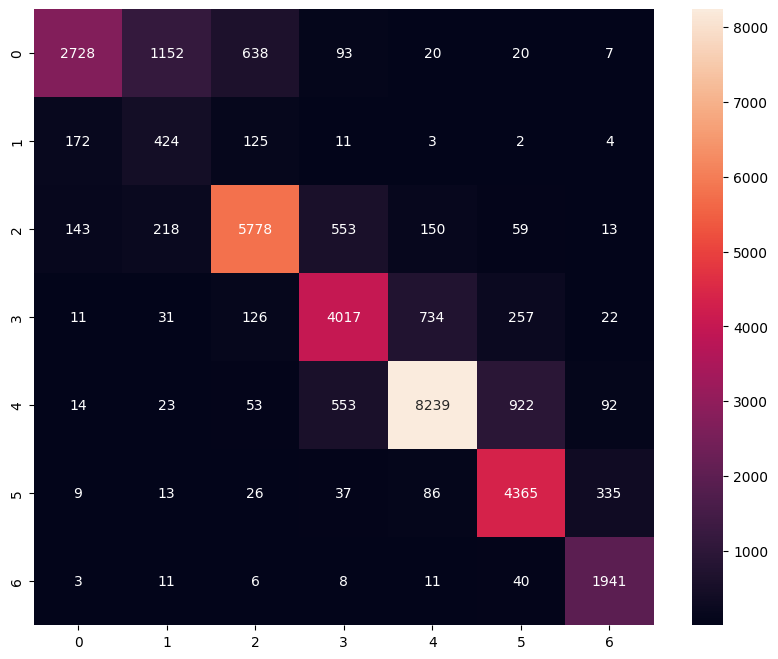

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_pad)
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test_cat.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()